# Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK Stopwords

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\laksh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Dataset

In [10]:
import pandas as pd
df = pd.read_csv(r"C:\Users\laksh\OneDrive\Desktop\ml project\IMDB Dataset.csv")
df.head()
df.shape

(50000, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


# Feature and Target Selection

In [12]:
X = df['review']
y = df['sentiment']

# Text Preprocessing

In [13]:
# Initialize tools
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [14]:
# Create preprocessing function
def preprocess_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

In [15]:
# Apply preprocessing
X_processed = X.apply(preprocess_text)
X_processed.head()

0    one review mention watch oz episod hook right ...
1    wonder littl product film techniqu unassum old...
2    thought wonder way spend time hot summer weeke...
3    basic famili littl boy jake think zombi closet...
4    petter mattei love time money visual stun film...
Name: review, dtype: object

# TF-IDF Feature Extraction

In [16]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X_processed)
print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (50000, 5000)


# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

# Train Naive Bayes Model

In [18]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8575


# Train Logistic Regression

In [19]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8892


# Train SVM Model

In [20]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8853


# Train Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8522


# Confusion Matrix for Best Model - Logistic Regression

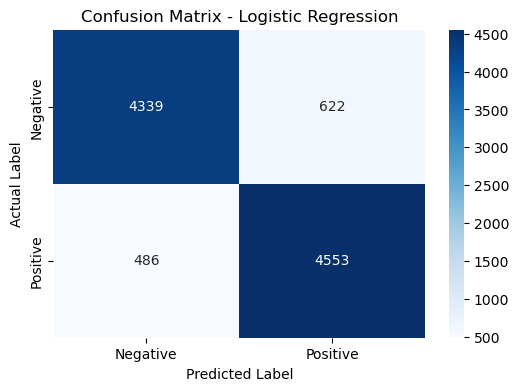

In [31]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# ROC-AUC Score

In [33]:
encoder = LabelEncoder()
y_test_num = encoder.fit_transform(y_test)
y_prob = lr_model.predict_proba(X_test)[:,1]
roc = roc_auc_score(y_test_num, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9594218512254286


# Model Comparision

In [34]:
results = pd.DataFrame({
    'Model':['Naive Bayes','Logistic Regression','SVM','Random Forest'],
    'Accuracy':[accuracy_nb, accuracy_lr, accuracy_svm, accuracy_rf]
})
print(results)

                 Model  Accuracy
0          Naive Bayes    0.8575
1  Logistic Regression    0.8892
2                  SVM    0.8853
3        Random Forest    0.8522


# Accuracy Visualization

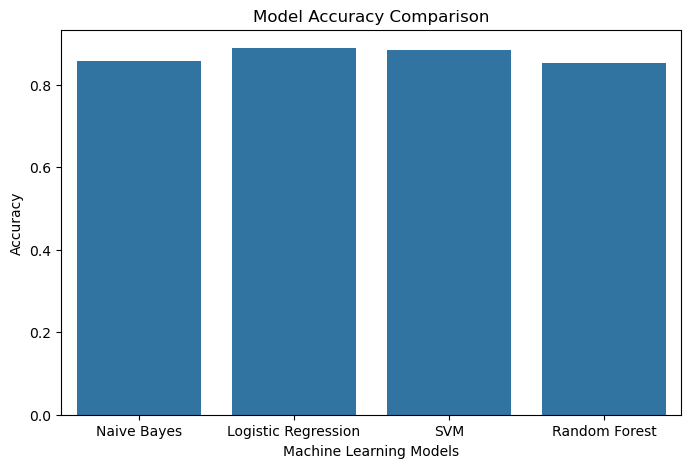

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

plt.show()

# Save Best Model

In [36]:

joblib.dump(lr_model,"sentiment_model.pkl")
joblib.dump(tfidf,"tfidf_vectorizer.pkl")

print("Model saved successfully")

Model saved successfully


# Predict Sentiment for New Review

In [37]:
def predict_sentiment(review):
    processed = preprocess_text(review)
    vector = tfidf.transform([processed])
    prediction = svm_model.predict(vector)
    return prediction[0]

In [40]:
# Test the model
review = input("Enter movie review: ")
print("Sentiment:", predict_sentiment(review))

Enter movie review:  "It is of time waste "


Sentiment: negative
